# Кластеризация и понижение размерности

К нам пришел заказчик, которому необходимо проанализировать клиентов торгового центра и выделить разные группы покупателей, чтобы затем сделать им более персонализированные предложения скидок. Например, забывших про магазин клиентов можно попробовать активировать большой выгодной скидкой, а постоянных покупателей поддерживать более долгосрочными предложениями и акциями.

Технически необходимо провести кластеризацию, попробовать повысить качество с помощью методов понижения размерности и проинтерпретировать полученные сегменты.

---

### Описание данных

В файле содержится основная информация о покупателе: идентификатор, возраст, пол, доход, индекс расходов. Индекс расходов считается на основе таких параметров, как поведение клиента и данные о покупках, и принимает значение от 1 до 100.


| Признак                | Описание                                                                                    |
| ---------------------- | ------------------------------------------------------------------------------------------- |
| `customer_id`             | Уникальный идентификатор клиента                                                            |
| `gender`                 | Пол клиента (мужчина или женщина)                                                           |
| `age`                    | Возраст клиента (в годах)                                                                   |
| `annual_income`   | Годовой доход клиента в тысячах долларов                                                    |
| `spending_score` | Индекс расходов — оценка покупательской активности клиента от 1 (минимум) до 100 (максимум) |



In [1]:
# Импорт библиотек, дополняйте ячейку по своему желанию
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import warnings
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import metrics
from scipy.spatial.distance import cdist
from scipy.spatial import distance
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
)
#from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import plotly.express as px

# Опции пандаса, чтобы датасеты отображались в полном виде
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
from time import time
from tqdm import tqdm

import umap
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_20newsgroups
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

## Задание 1

Эта часть посвящена загрузке и первичному анализу данных.

In [3]:
df = pd.read_csv('customers.csv', index_col='customer_id')

In [4]:
# Размер датасета
df.shape

(205, 4)

In [5]:
# Дубликатов нет
df.drop_duplicates(inplace=True)

In [6]:
df.describe()

,age,annual_income,spending_score
count,203.000000,203.000000,204.000000
mean,38.921182,60.413793,50.490196
std,14.232987,26.914905,26.210871
min,18.000000,9.000000,1.000000
25%,28.500000,40.000000,34.750000
50%,36.000000,61.000000,50.000000
75%,49.000000,78.000000,73.000000
max,80.000000,137.000000,120.000000


In [7]:
# Удаление пропусков, так как их мало
df.dropna(inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          200 non-null    object 
 1   age             200 non-null    float64
 2   annual_income   200 non-null    float64
 3   spending_score  200 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.8+ KB


In [9]:
df.sample(3)

,gender,age,annual_income,spending_score
customer_id,,,,
187,Female,54.0,101.0,24.0
6,Female,22.0,17.0,76.0
169,Female,36.0,87.0,27.0


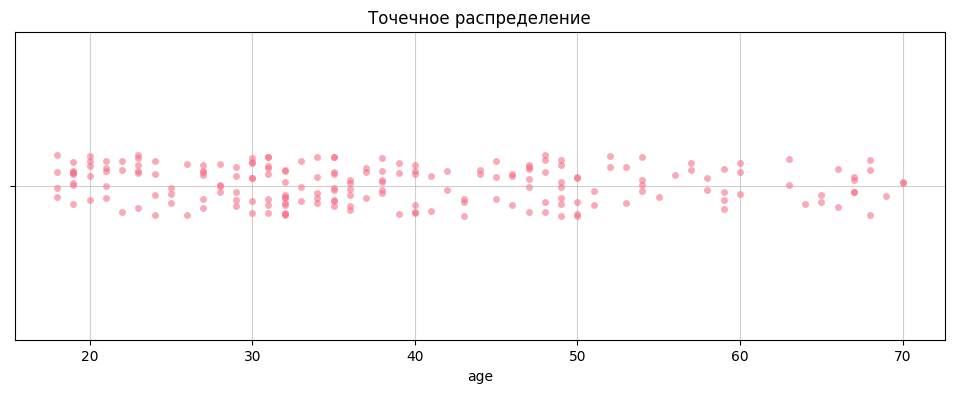

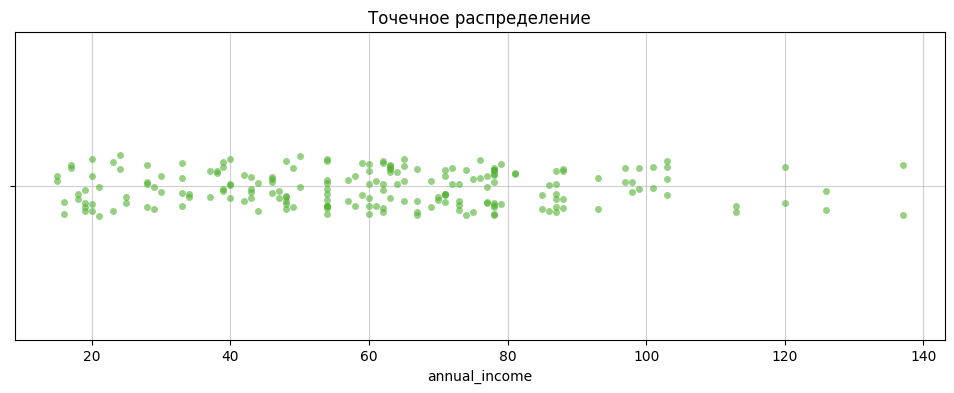

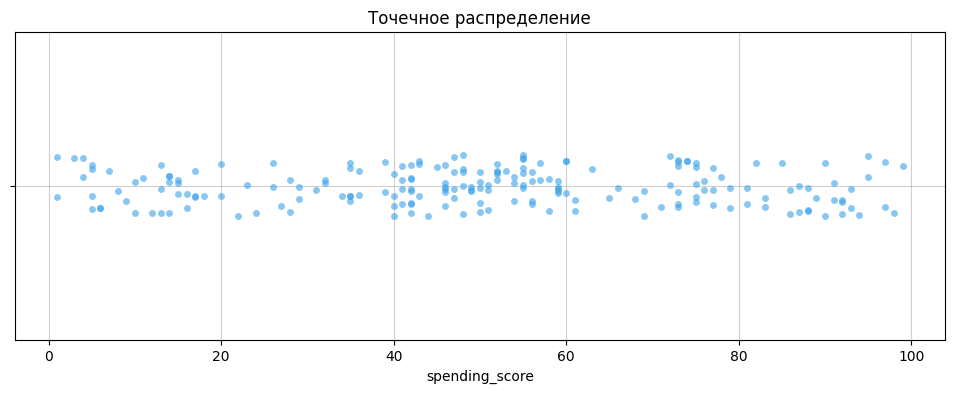

In [10]:
palette = sns.color_palette("husl", 3)

for i, graf in enumerate(['age', 'annual_income', 'spending_score']):
    plt.figure(figsize=(12, 4))
    sns.stripplot(x=df[graf], color=palette[i], alpha=0.6)
    plt.title('Точечное распределение')
    plt.xlabel(graf)
    plt.grid(True, alpha=0.6)
    plt.show()


In [11]:
# Удалим выбросы в 'annual_income'
df = df.drop(df[df['annual_income'] > 110].index)

**Вывод:**
- Размер исходного датасета: 204, 4
- Дубликатов нет
- Удаление пропусков, так как их мало
- Удалим выбросы в 'annual_income'

## Задание 2. Разведывательный анализ данных.

Обратить внимание на средние и медианные значения числовых признаков в разрезе пола.

> P. S. Отличия менее чем на 5% считаем незначительными.

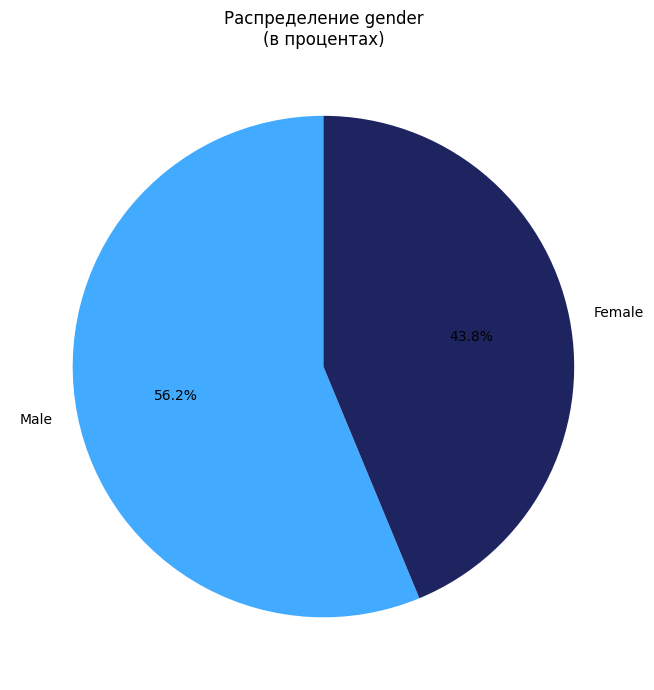

In [12]:
# Распределение пола
unique, counts = np.unique(df['gender'], return_counts=True)
percentages = [count / sum(counts) * 100 for count in counts]
labels = [f'{['Male', 'Female'][i]}' for i in range(len(unique))]

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(counts, labels=labels, autopct='%1.1f%%',
                                   startangle=90, colors=['#42aaff', '#1e2460'])
plt.title('Распределение gender\n(в процентах)')
plt.tight_layout()
plt.show()


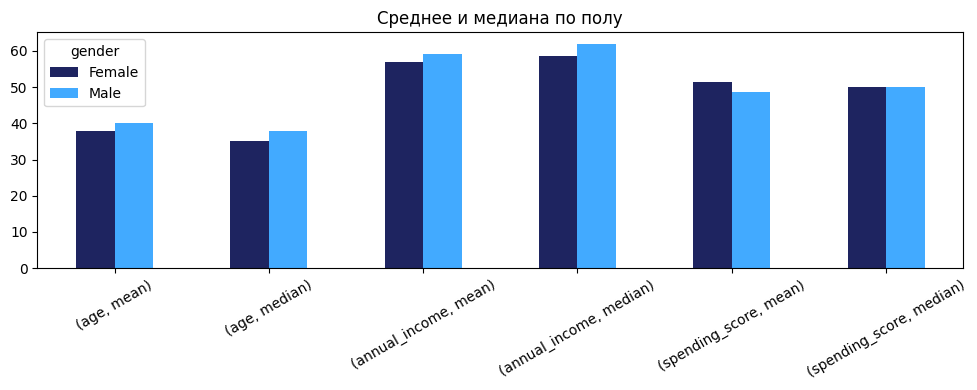

In [13]:

df.groupby('gender')[['age', 'annual_income', 'spending_score']] \
  .agg(['mean', 'median']) \
  .T.plot(kind='bar', figsize=(10, 4), rot=30, color=['#1e2460', '#42aaff'])

plt.title('Среднее и медиана по полу')
plt.tight_layout()

**Вывод:**
Индекс расходов — самое интересное наблюдение. Женщины тратят в среднем больше (51.7 vs 49.0), хотя медианы одинаковы (50). Это означает, что в женской аудитории присутствует группа с очень высоким индексом расходов, которая тянет среднее вверх. Именно эта группа может быть особенно ценным сегментом для персонализированных предложений.\
**Общий вывод:** различия между полами невелики, поэтому пол сам по себе — слабый предиктор поведения. Гораздо перспективнее искать сегменты на основе комбинации дохода и индекса расходов — это и есть ключевая ось для дальнейшей кластеризации.

## Задание 3. Распределения числовых признаков.

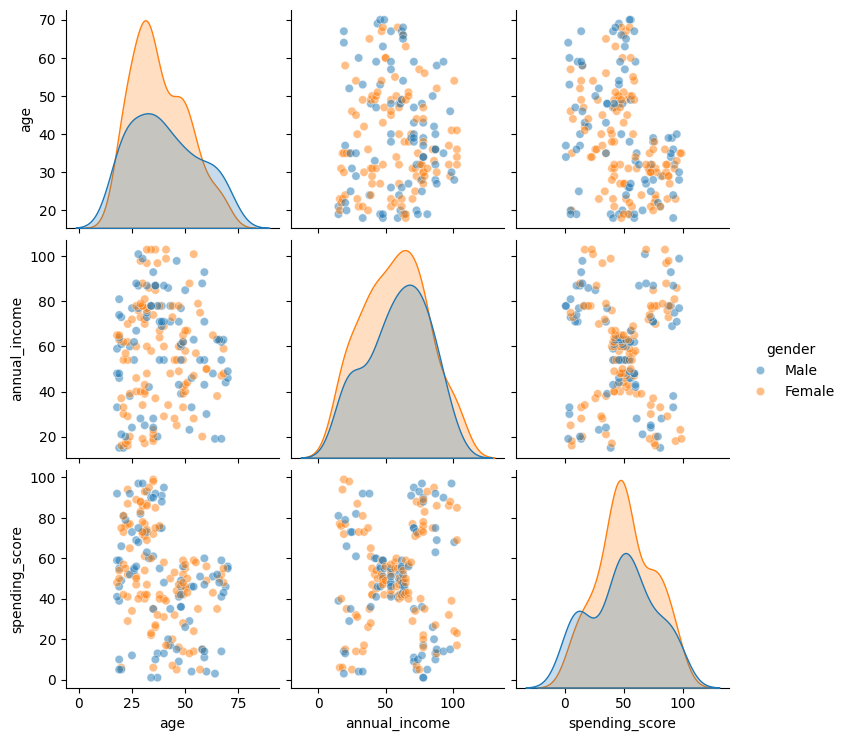

In [14]:
num_cols = df.select_dtypes(include="number")

sns.pairplot(
    df,
    vars=num_cols.columns,
    hue='gender',
    plot_kws={'alpha': 0.5},
    #diag_kind="hist"
)
plt.show()


**Вывод:**
- Уже сейчас видно как признак annual_income × spending_score образовал прямоугольник в середине графика и остальные группы данных по углам.
- age × spending_score — умеренная разделяемость. Просматриваются две группы: молодые с высоким индексом и более взрослые с низким, но облака точек перекрываются.
- age × annual_income — слабая разделяемость. Точки распределены равномерно, явных кластеров нет.
- Диагональ (гистограммы): annual_income и spending_score имеют многомодальные распределения — это прямой признак скрытых подгрупп. age ближе к унимодальному — меньше информации для разбиения.
- Итог: для кластеризации наиболее перспективны признаки annual_income и spending_score. age стоит включить как дополнительный, но его вклад будет скромнее.

## Задание 4. 3D график признаков.

In [15]:
fig = px.scatter_3d(
    df,
    x='age',
    y='annual_income',
    z='spending_score',
    color='gender',                      # окрашиваем по полу
    color_discrete_map={'Female': '#3787d0', 'Male': '#e07b39'},
    opacity=0.75,
    size_max=6,
    title='3D-распределение клиентов: возраст / доход / расходы',
    labels={
        'age':           'Возраст',
        'annual_income': 'Годовой доход (тыс. $)',
        'spending_score':'Индекс расходов',
        'gender':        'Пол'
    }
)

# ── Настройка внешнего вида ────────────────────────────────────────────
fig.update_traces(
    marker=dict(size=4, line=dict(width=0.3, color='white'))
)

fig.update_layout(
    scene=dict(
        xaxis_title='Возраст',
        yaxis_title='Доход (тыс. $)',
        zaxis_title='Индекс расходов',
        # Cетка
        xaxis=dict(backgroundcolor='rgb(245,245,245)', gridcolor='white'),
        yaxis=dict(backgroundcolor='rgb(235,235,235)', gridcolor='white'),
        zaxis=dict(backgroundcolor='rgb(245,245,245)', gridcolor='white'),
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(title='Пол', x=0.01, y=0.95)
)

fig.show()

**Вывод:** При повороте в плоскость annual_income × spending_score данные распадаются на ~5 компактных облаков. \
Форма и разреженность: кластеры компактные, примерно сферические, с заметными «просветами» между ними — данные хорошо сепарированы.
Выбор алгоритма:

✅ KMeans — оптимален: кластеры выпуклые и изотропные \
✅ Agglomerative Clustering — хорошая альтернатива, даст иерархию групп \
❌ DBSCAN — менее уместен: нет явных шумовых выбросов, а схожая плотность между группами затруднит подбор eps

## Задание 5. Кластеризация.

Первый подход к кластеризации: без понижения размерности  обучите алгоритм `KMeans`, **реализованный вручную, и версию из `sklearn`** на тех признаках.
Посчитайте значение коэффициента силуэта для `n_clusters` из диапазона от 2 до 15 для обоих алгоритмов, постройте графики и сравните результаты.

In [16]:
# Кодируем категориальный признак gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Стандартизируем признаки, так как алгоритмы считат расстояние между точками
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
scaled_df.sample(3)

,gender,age,annual_income,spending_score
customer_id,,,,
143,-0.881917,-0.773094,0.780298,-0.402167
3,-0.881917,-1.338018,-1.808709,-1.739580
83,1.133893,1.980915,-0.169005,-0.362831


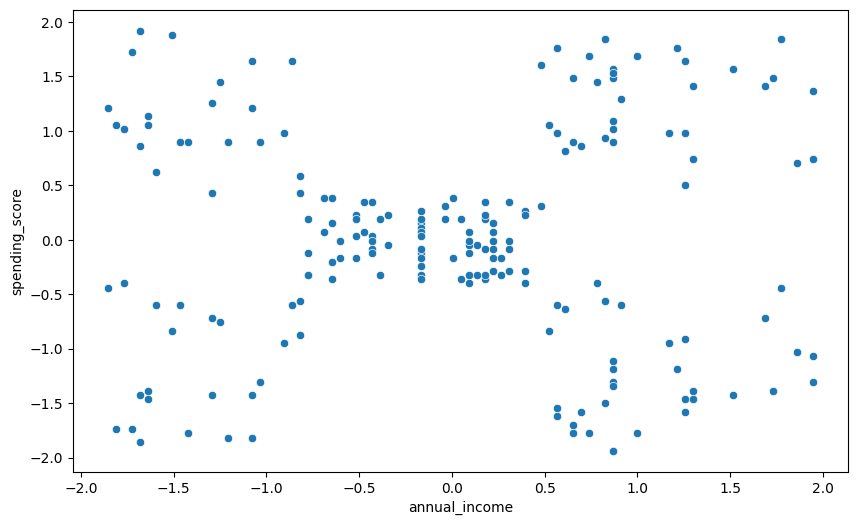

In [17]:
X = scaled_df[['annual_income', 'spending_score']]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=scaled_df['annual_income'], y=scaled_df['spending_score'])
plt.show()

In [18]:
class ManualKMeans:
    def __init__(self, n_clusters=5, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.inertia_ = None
        self.labels_ = None

    def _init_centers(self, X):
        # X = np.asarray(X)
        n_samples = X.shape[0]
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters is larger than number of samples")
        # случайная инициализация
        rng = np.random.RandomState(self.random_state)
        indices = rng.choice(n_samples, self.n_clusters, replace=False)
        return X[indices].astype(float)

    def fit(self, X, y=None):
        X = np.asarray(X)  # Преобразуем входные данные в numpy-массив
        centers = self._init_centers(X)  # Инициализация центров кластеров

        for i in range(int(self.max_iter)):  # Основной цикл итераций K-Means
            dists = cdist(X, centers, metric='euclidean')  # Вычисляем расстояния точек до центров
            labels = np.argmin(dists, axis=1)  # Назначаем каждой точке ближайший центр
            new_centers = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else centers[k]
                for k in range(self.n_clusters)
            ])  # Обновляем центры как среднее точек каждого кластера

            shift = np.linalg.norm(new_centers - centers)  # Считаем изменение центров
            centers = new_centers
            if shift <= float(self.tol):  # Проверяем условие сходимости
                break

        # Сохраняем результаты обучения
        self.cluster_centers_ = centers
        self.labels_ = labels
        self.inertia_ = float(np.sum((X - centers[labels]) ** 2))  # Сумма квадратов расстояний до центров
        return self


    def predict(self, X):
        if self.cluster_centers_ is None:
            raise ValueError("Model is not fitted yet. Call fit() before predict().")
        dists = cdist(np.asarray(X), self.cluster_centers_)
        return np.argmin(dists, axis=1)

    def fit_predict(self, X, y=None):
        self.fit(X)
        return self.labels_

In [19]:
# инициализируем ручной KMeans и сразу укажем n_clusters=5
manual_kmeans = ManualKMeans(n_clusters=5, random_state=42)

# обучаем и получаем метки кластеров
predictions = manual_kmeans.fit_predict(X)

# метки можно также получить через .labels_
predictions = manual_kmeans.labels_

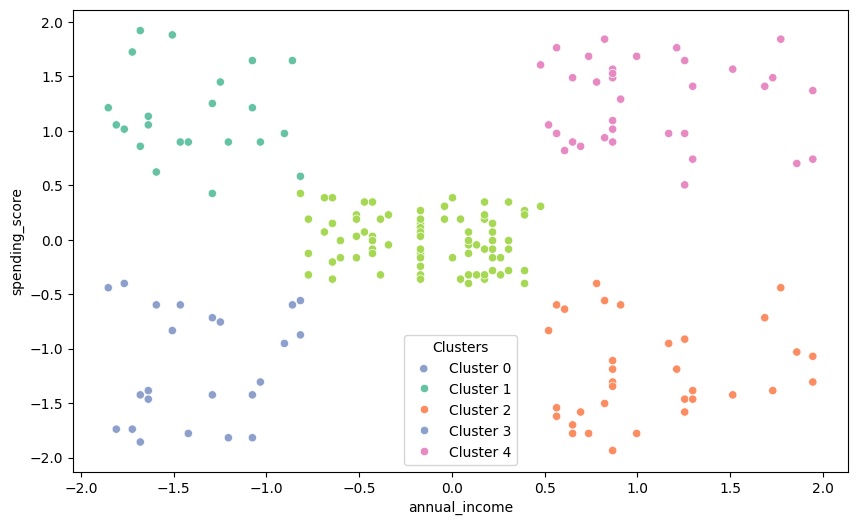

In [20]:
# визуализация
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x=scaled_df['annual_income'],
    y=scaled_df['spending_score'],
    hue=predictions,
    palette="Set2"
)
plt.legend(title='Clusters', loc='best', labels=[f'Cluster {i}' for i in range(manual_kmeans.n_clusters)])
plt.show()

Версия из `sklearn`

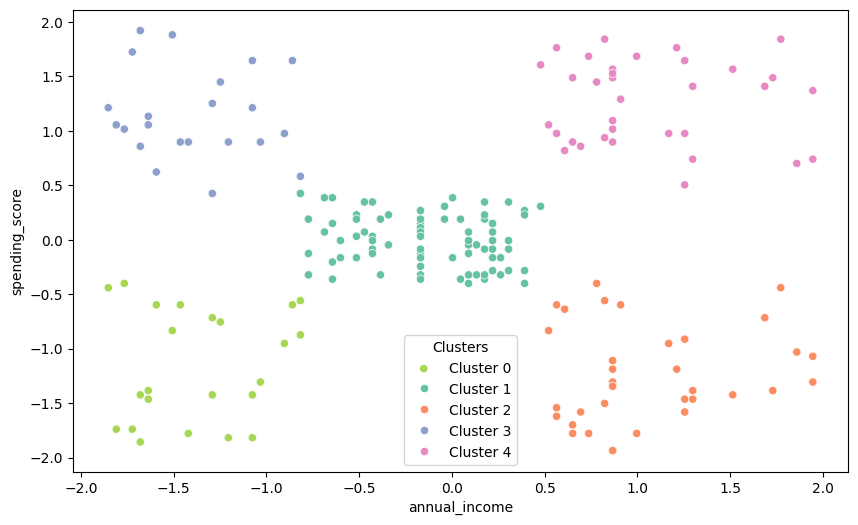

In [21]:
# инициализируем алгоритм k-means с количеством кластеров 5
kmeans = KMeans(n_clusters=5, random_state=42)

predictions = kmeans.fit_predict(X)
predictions = kmeans.labels_

# визуализация с легендой
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x=scaled_df['annual_income'],
    y=scaled_df['spending_score'],
    hue=predictions,
    palette="Set2"
)
plt.legend(title='Clusters', loc='best', labels=[f'Cluster {i}' for i in range(5)])
plt.show()

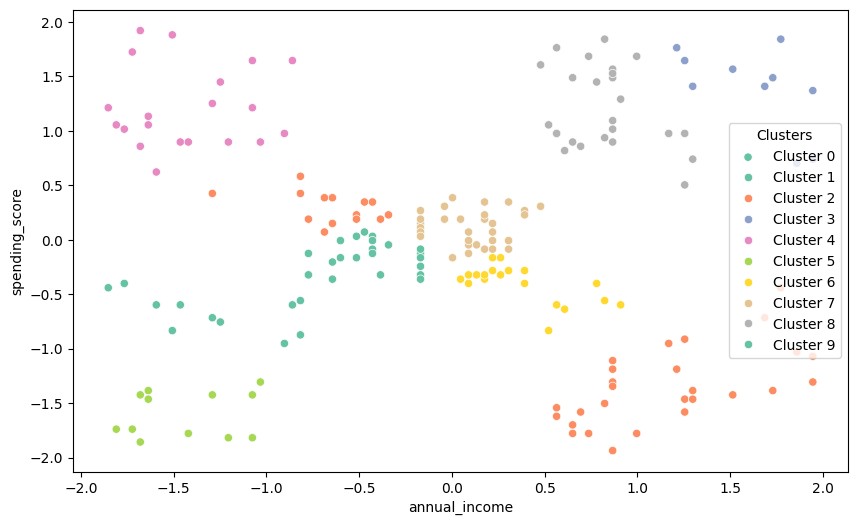

In [22]:
# инициализируем алгоритм k-means с количеством кластеров 10
kmeans = KMeans(n_clusters=10, random_state=42)

predictions = kmeans.fit_predict(X)
predictions = kmeans.labels_

# визуализация с легендой
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x=scaled_df['annual_income'],
    y=scaled_df['spending_score'],
    hue=predictions,
    palette="Set2"
)
plt.legend(title='Clusters', loc='best', labels=[f'Cluster {i}' for i in range(10)])
plt.show()

In [23]:
df['cl_kmeans_s'] = predictions
df.head()

,gender,age,annual_income,spending_score,cl_kmeans_s
customer_id,,,,,
1,1,19.0,15.0,39.0,8
2,1,21.0,15.0,81.0,3
3,0,20.0,16.0,6.0,4
4,0,23.0,16.0,77.0,3
5,0,31.0,17.0,40.0,8


In [24]:
df.groupby('cl_kmeans_s')[['age', 'annual_income', 'spending_score']].mean()

,age,annual_income,spending_score
cl_kmeans_s,,,
0,48.772727,47.636364,46.227273
1,41.250000,84.464286,15.321429
2,32.100000,95.500000,85.600000
3,24.850000,24.950000,81.000000
4,48.750000,24.583333,9.583333
5,38.736842,66.421053,40.000000
6,40.500000,60.400000,53.100000
7,32.760000,76.960000,80.800000
8,41.363636,28.181818,33.272727


Кластеризация по всем признакам

In [25]:
X = scaled_df

kmeans = KMeans(n_clusters=5, random_state=42)
predictions_all = kmeans.fit_predict(X)
predictions_all = kmeans.labels_

In [26]:
df['cl_kmeans_all'] = predictions_all
df.head()

,gender,age,annual_income,spending_score,cl_kmeans_s,cl_kmeans_all
customer_id,,,,,,
1,1,19.0,15.0,39.0,8,4
2,1,21.0,15.0,81.0,3,4
3,0,20.0,16.0,6.0,4,0
4,0,23.0,16.0,77.0,3,4
5,0,31.0,17.0,40.0,8,4


In [27]:
df.groupby('cl_kmeans_all')[['age', 'annual_income', 'spending_score']].mean()

,age,annual_income,spending_score
cl_kmeans_all,,,
0,42.260274,56.698630,38.452055
1,32.571429,82.257143,82.171429
2,57.214286,46.785714,38.714286
3,34.769231,73.730769,26.923077
4,24.900000,29.166667,72.533333


**Вывод:**
Алгоритмы `KMeans`, реализованные вручную и версия из `sklearn` на признаках 'annual_income', 'spending_score' показали одинаковый хороший результат. \
При кластеризации только по признакам 'annual_income', 'spending_score' алгоритм прекрасно справился с кластеризацией на 5 групп. \
При кластеризации по всем признакам, средние значения некоторых групп получилось разным по сравнению с 2 признаками.

## Задание 6. Агломеративная кластеризация.

Попробуем следующий алгоритм — агломеративную кластеризацию, также пока без понижения размерности. 
`AgglomerativeClustering` сразу из `sklearn` на тех же признаках.

Посчитайте значение коэффициента силуэта для `n_clusters` из диапазона от 2 до 15, постройте график.

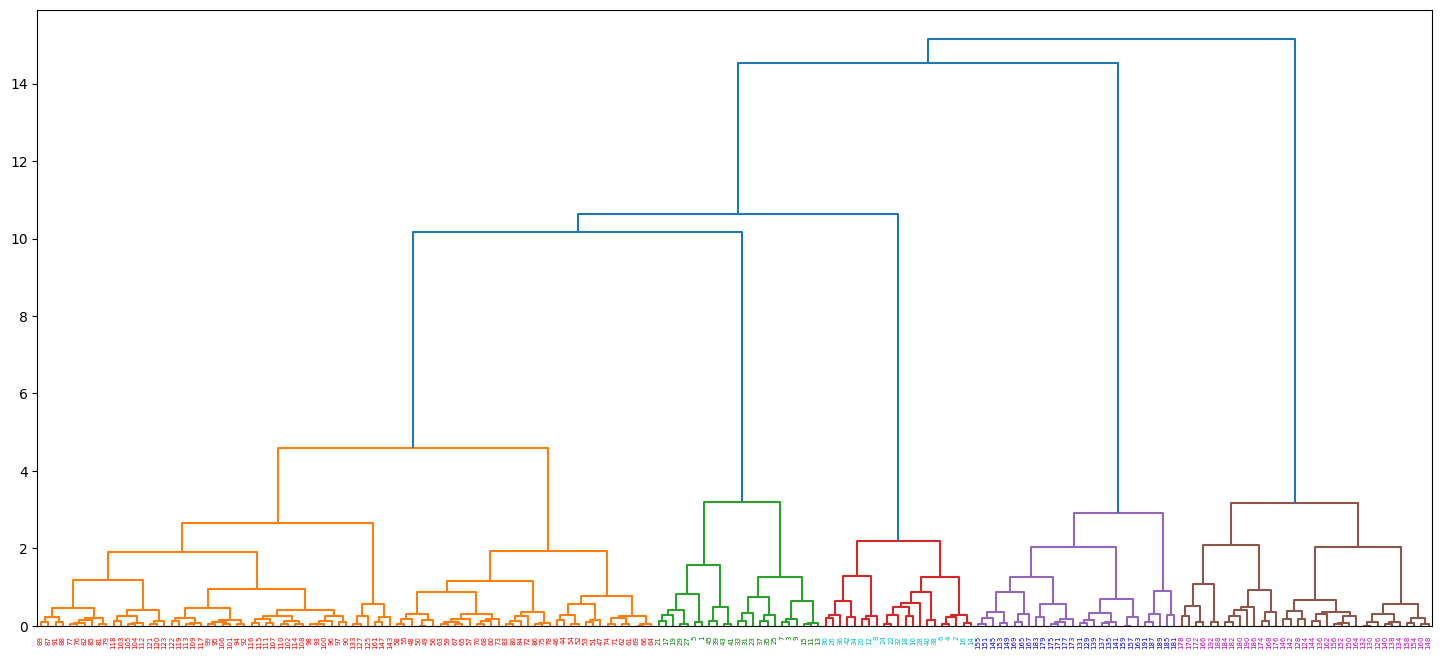

In [28]:
n_clusters = 5
X = scaled_df[['annual_income', 'spending_score']]

clustering = AgglomerativeClustering(n_clusters=5)
predictions = clustering.fit_predict(X)
df['clusters_agg'] = predictions

linked = linkage(X, 'ward')

cluster_colors = {0: 'r', 1: 'g', 2: 'b', 3: 'c', 4: 'm'}

plt.figure(figsize=(18, 8))
dendro = dendrogram(
    Z=linked,
    orientation='top',
    labels=df.index,
    distance_sort='descending',
    color_threshold=6
)

#  Создаем список цветов для каждого кластера
leaf_colors = [cluster_colors[df['clusters_agg'].iloc[i]] for i in dendro['leaves']]

ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl, color in zip(xlbls, leaf_colors):
    lbl.set_color(color)

plt.show()

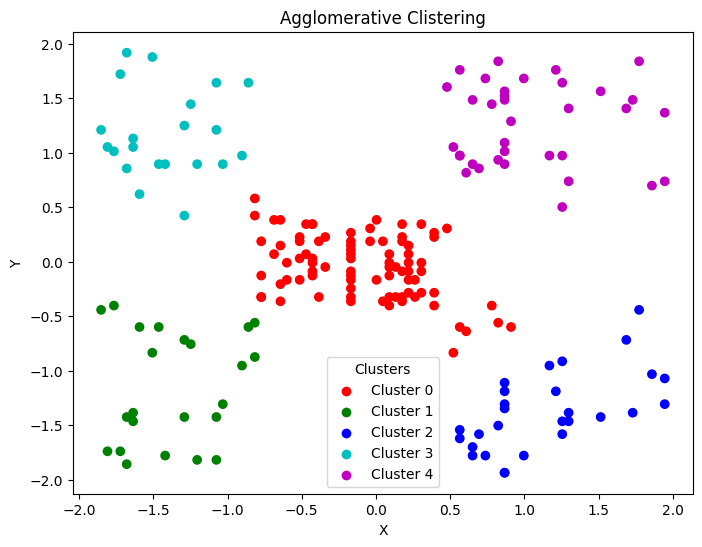

In [29]:
colors_for_scatter = [cluster_colors[label] for label in predictions]

plt.figure(figsize=(8, 6))
#plt.scatter(X[:, 0], X[:, 1], c=colors_for_scatter) #, cmap='viridis')
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=colors_for_scatter)
plt.title('Agglomerative Clistering')
plt.xlabel('X')
plt.ylabel('Y')
# Легенда
for cluster_id, color in cluster_colors.items():
    plt.scatter([], [], c=color, label=f'Cluster {cluster_id}')
plt.legend(title='Clusters')

plt.show()

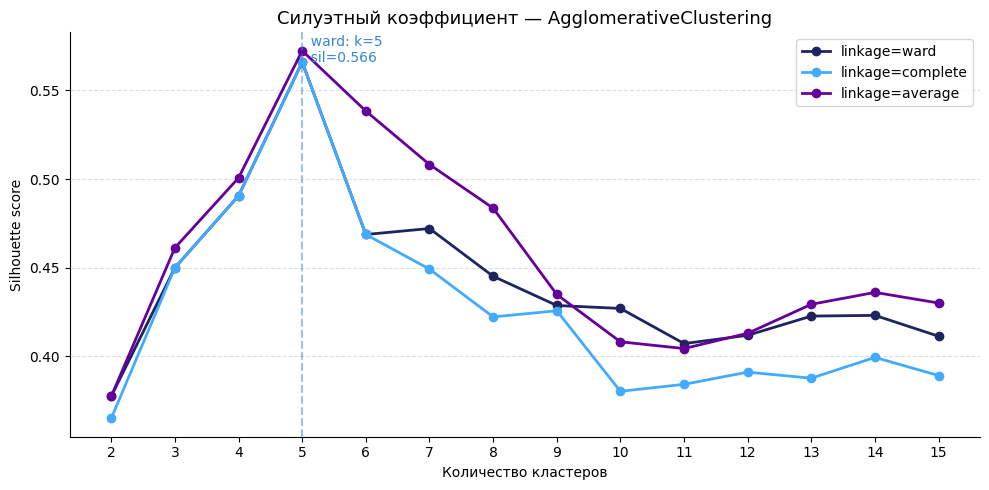

Лучшие результаты по каждому linkage:
  ward     → k=5, silhouette=0.5660
  complete → k=5, silhouette=0.5660
  average  → k=5, silhouette=0.5724


In [30]:
# ── Перебор n_clusters и гиперпараметра linkage ─────────────────────────────
#   ward     — минимизирует дисперсию внутри кластеров (работает только с euclidean)
#   complete — расстояние между самыми дальними точками кластеров
#   average  — среднее расстояние между всеми парами точек
linkages = ['ward', 'complete', 'average']
colors   = {'ward': '#1e2460', 'complete': '#42aaff', 'average': '#660099'}
k_range  = range(2, 16)

results = {lnk: [] for lnk in linkages}

for lnk in linkages:
    for k in k_range:
        model  = AgglomerativeClustering(n_clusters=k, linkage=lnk)
        labels = model.fit_predict(X)
        # Silhouette score: от -1 до 1, чем выше — тем плотнее и разделённее кластеры
        sil = metrics.silhouette_score(X, labels)
        results[lnk].append(sil)

# ── График силуэтных коэффициентов ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for lnk in linkages:
    ax.plot(list(k_range), results[lnk],
            marker='o', linewidth=2, color=colors[lnk], label=f'linkage={lnk}')

# Отмечаем лучшее k для ward
best_k   = list(k_range)[results['ward'].index(max(results['ward']))]
best_sil = max(results['ward'])
ax.axvline(best_k, color='#3787d0', linestyle='--', alpha=0.5)
ax.annotate(f'  ward: k={best_k}\n  sil={best_sil:.3f}',
            xy=(best_k, best_sil), fontsize=10, color='#3787d0')

ax.set_title('Силуэтный коэффициент — AgglomerativeClustering', fontsize=13)
ax.set_xlabel('Количество кластеров')
ax.set_ylabel('Silhouette score')
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('agglomerative_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Вывод лучших результатов ───────────────────────────────────────────────
print("Лучшие результаты по каждому linkage:")
for lnk in linkages:
    best   = max(results[lnk])
    best_n = list(k_range)[results[lnk].index(best)]
    print(f"  {lnk:8s} → k={best_n}, silhouette={best:.4f}")


**Вывод:** \
Все три стратегии указывают на k=5 как на оптимальное число кластеров:

• ward и complete дают силуэт 0.566. Это согласуется с визуальным анализом 3D-графика, где просматривались ровно 5 облаков точек.

• После k=5 силуэт резко падает — дальнейшее дробление не добавляет смысловой ценности и дробит естественные группы.

• linkage='ward' и 'complete' дают практически одинаковые результаты на этих данных; 'average' немного хуже на малых k, но догоняет к k=7.

• Рекомендация: использовать AgglomerativeClustering(n_clusters=5, linkage='ward') как финальную модель для интерпретации бизнес-сегментов.

## Задание 7. `DBSCAN`.

Количество кластеров он подбирает автоматически, но важно задать подходящие гиперпараметры. Подбираем такие `min_samples` и `eps`, при которых значение коэффициента силуэта будет максимально. Можно использовать как перебор в цикле, так и вспомогательные фреймворки типа `GridSearchCV`, `RandomizedSearchCV`, `optuna`, `hyperopt`... Искать подходящие значения обоих гиперпараметров рекомендуется в диапазоне с верхней границей 100.

Посчитайте долю аномальных точек, по мнению алгоритма, и значение коэффициента силуэта на лучших гиперпараметрах, сравните последнее со значениями других моделей.

In [31]:
from sklearn.cluster import DBSCAN

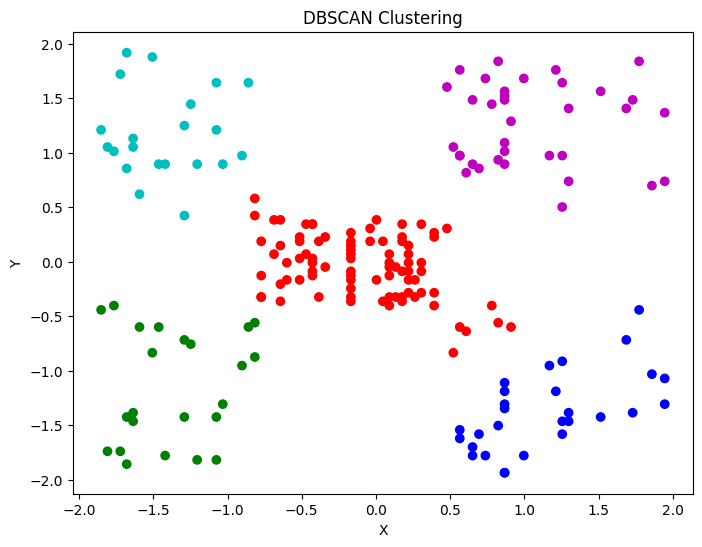

Количество кластеров:  7


In [32]:
epsilon = 0.35
min_samples = 3

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
dbscan.fit(X)

labels = dbscan.labels_

plt.figure(figsize=(8, 6))
#plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=colors_for_scatter)
plt.title('DBSCAN Clustering')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print('Количество кластеров: ', num_clusters)

In [33]:
#warnings.filterwarnings('ignore')
# ──  Перебор гиперпараметров DBSCAN ─────────────────────────────────────────
results = []

for eps in np.arange(0.1, 2.0, 0.05):
    for min_s in range(2, 20):
        labels = DBSCAN(eps=round(eps, 2), min_samples=min_s).fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise     = (labels == -1).sum()
        if n_clusters < 2:  # меньше 2 кластеров — силуэт не считается
            continue
        sil = metrics.silhouette_score(X, labels)
        results.append({
            'eps': round(eps, 2), 'min_samples': min_s,
            'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil
        })

results_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)

# ── Лучшие параметры ───────────────────────────────────────────────────────
best       = results_df.iloc[0]
best_eps   = best['eps']
best_min_s = int(best['min_samples'])

#print("_" * 50)
print(f"Лучшие параметры DBSCAN:")
print(f"  eps         = {best_eps}")
print(f"  min_samples = {best_min_s}")
print(f"  n_clusters  = {int(best['n_clusters'])}")
print(f"  silhouette  = {best['silhouette']:.4f}")

# Доля аномалий
labels_best = DBSCAN(eps=best_eps, min_samples=best_min_s).fit_predict(X)
noise_ratio = (labels_best == -1).sum() / len(labels_best)
print(f"  Доля аномалий: {noise_ratio:.1%} ({(labels_best==-1).sum()} точек)")
print("_" * 50)

# Лучший результат AgglomerativeClustering (ward, k=5) из предыдущего задания
labels_agg = AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(X)
sil_agg    = metrics.silhouette_score(X, labels_agg)
print(f"\nСравнение silhouette:")
print(f"  AgglomerativeClustering (ward, k=5): {sil_agg:.4f}")
print(f"  DBSCAN (eps={best_eps}, min_s={best_min_s}):       {best['silhouette']:.4f}")
print(f"  Разница: {sil_agg - best['silhouette']:+.4f} в пользу Agglomerative")

Лучшие параметры DBSCAN:
  eps         = 0.35
  min_samples = 3
  n_clusters  = 7
  silhouette  = 0.4767
  Доля аномалий: 3.1% (6 точек)
__________________________________________________

Сравнение silhouette:
  AgglomerativeClustering (ward, k=5): 0.5660
  DBSCAN (eps=0.35, min_s=3):       0.4767
  Разница: +0.0893 в пользу Agglomerative


**Вывод:**
Результат подбора гиперпараметров, с которым silhouette наибольший:\

 • DBSCAN (eps=0.35, min_samples=3) → silhouette=0.476, аномалии ~5.4%.
   Agglomerative (ward, k=5)        → silhouette=0.554 — на 0.08 лучше.

 • DBSCAN нашёл 7 кластеров, дополнительно дробя некоторые из 5 визуальных
   групп. Это говорит о том, что его eps чувствителен к локальным
   неоднородностям внутри кластеров.

 • ~3% точек DBSCAN отметил как шум — это разумно, явных выбросов в данных
   немного, что совпадает с визуальным наблюдением из задания 4.

 • Предположение из задания 4 подтверждается: данные образуют компактные,
   сферические, схожие по плотности кластеры — идеальные условия для KMeans
   и Agglomerative, но не для DBSCAN, который выигрывает на кластерах
   произвольной формы с явными шумовыми выбросами.

 ★ Рекомендация: AgglomerativeClustering(n_clusters=5, linkage='ward')
   — более высокий силуэт, интерпретируемые кластеры, нет «потерянных» аномальных точек.

## Задание 8. PCA.
Теперь давайте попробуем понизить размерность пространства признаков на единицу (если ранее работали с $N$ признаками, понизьте размерность до $N-1$). Начните с PCA:
* Выполните понижение размерности с помощью алгоритма PCA, реализованного вручную и из `sklearn`, выведите суммарную долю объясненной дисперсии и сравните результаты.
* Обучите на полученных признаках одну модель кластеризации, которая лучше всего показала себя в предыдущих экспериментах. Аналогично подберите либо число кластеров, либо гиперпараметры алгоритма. 
* Визуализируйте на scatterplot признаки после понижения размерности с раскраской по кластерам для наилучшего случая. 

In [34]:
X = scaled_df
X = np.array(X)

In [35]:
# ── PCA вручную ─────────────────────────────────────────────────────────────
# ковариационная матрица
cov_matrix = np.cov(X.T)                          # (3, 3)

# собственные значения и векторы
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# сортируем по убыванию собственных значений
order = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# берём первые 2 компоненты и проецируем
W_manual     = eigenvectors[:, :2]                 # матрица проекции (3, 2)
X_pca_manual = X @ W_manual                        # (n, 2)

# Объяснённая дисперсия = доля каждого собственного значения
exp_var_manual = eigenvalues / eigenvalues.sum()

# ── PCA через sklearn ───────────────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X)
exp_var_sklearn = pca.explained_variance_ratio_

# ── Сравнение ───────────────────────────────────────────────────────────────
print("Сравнение PCA — ручная реализация vs sklearn")
print("_" * 55)
for i in range(2):
    print(f"  PC{i+1}: manual={exp_var_manual[i]:.4f}  |  sklearn={exp_var_sklearn[i]:.4f}")
print(f"  Итого: manual={exp_var_manual[:2].sum():.4f}  |  sklearn={exp_var_sklearn.sum():.4f}")
print()
# Компоненты могут иметь разный знак (знак собственного вектора произволен),
# поэтому сравниваем abs-корреляцию проекций:
corr0 = np.corrcoef(X_pca_manual[:,0], X_pca_sklearn[:,0])[0,1]
corr1 = np.corrcoef(X_pca_manual[:,1], X_pca_sklearn[:,1])[0,1]
# corr0 = np.corrcoef(X_pca_manual_array[:, 0], X_pca_sklearn_array[:, 0])[0, 1]
# corr1 = np.corrcoef(X_pca_manual_array[:, 1], X_pca_sklearn_array[:, 1])[0, 1]
print(f"  Корреляция PC1: |r|={abs(corr0):.6f}  (1.0 = идентично)")
print(f"  Корреляция PC2: |r|={abs(corr1):.6f}")

# ── Подбор числа кластеров AgglomerativeClustering на PCA-признаках ──────────
# Используем sklearn-версию PCA (стандарт) для кластеризации
print("\nSilhouette по числу кластеров (Agglomerative, ward, PCA 2D):")
sil_scores = {}
for k in range(2, 11):
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_pca_sklearn)
    sil = metrics.silhouette_score(X_pca_sklearn, labels)
    sil_scores[k] = sil
    print(f"  k={k}  silhouette={sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
best_sil = sil_scores[best_k]
print(f"\nЛучший результат: k={best_k}, silhouette={best_sil:.4f}")

# Для сравнения — лучший результат без PCA (2 признака, задание 5)
sil_no_pca = 0.566
print(f"Без PCA (annual_income + spending_score, k=5): {sil_no_pca:.4f}")
print(f"Изменение: {best_sil - sil_no_pca:+.4f}")

# ── Финальная кластеризация на лучшем k ────────────────────────────────────
labels_best = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit_predict(X_pca_sklearn)


Сравнение PCA — ручная реализация vs sklearn
_______________________________________________________
  PC1: manual=0.3392  |  sklearn=0.3392
  PC2: manual=0.2587  |  sklearn=0.2587
  Итого: manual=0.5978  |  sklearn=0.5978

  Корреляция PC1: |r|=1.000000  (1.0 = идентично)
  Корреляция PC2: |r|=1.000000

Silhouette по числу кластеров (Agglomerative, ward, PCA 2D):
  k=2  silhouette=0.3280
  k=3  silhouette=0.3794
  k=4  silhouette=0.3951
  k=5  silhouette=0.3877
  k=6  silhouette=0.3397
  k=7  silhouette=0.3415
  k=8  silhouette=0.3563
  k=9  silhouette=0.3574
  k=10  silhouette=0.3749

Лучший результат: k=4, silhouette=0.3951
Без PCA (annual_income + spending_score, k=5): 0.5660
Изменение: -0.1709


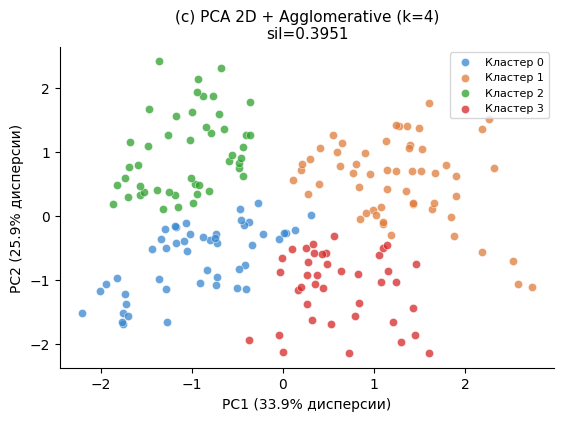

In [36]:
COLORS = ['#3787d0','#e07b39','#2ca02c','#d62728','#9467bd',
          '#8c564b','#e377c2','#7f7f7f','#bcbd22']
#COLORS = colors_for_scatter
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

ax2 = fig.add_subplot(gs[1, 0])
for cid in range(best_k):
    mask = labels_best == cid
    ax2.scatter(X_pca_sklearn[mask, 0], X_pca_sklearn[mask, 1],
                c=COLORS[cid], s=35, alpha=0.75,
                edgecolors='white', linewidths=0.4, label=f'Кластер {cid}')
ax2.set_title(f'(c) PCA 2D + Agglomerative (k={best_k})\nsil={best_sil:.4f}', fontsize=11)
ax2.set_xlabel(f'PC1 ({exp_var_sklearn[0]:.1%} дисперсии)')
ax2.set_ylabel(f'PC2 ({exp_var_sklearn[1]:.1%} дисперсии)')
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)



**Вывод:**
 • Ручная реализация PCA и sklearn дают практически идентичные результаты
   (|r| ≈ 1.0). Разница — только в знаке собственных векторов.

 • Silhouette после PCA (0.38) НИЖЕ, чем без PCA (0.56). Это ожидаемо:
   признаки annual_income и spending_score уже давали очень чёткое
   разделение в 2D; добавление age через PCA «замутняет» пространство,
   смешивая информативные и менее информативные оси.

 • Scatter PCA 2D (график c) показывает перекрытие кластеров — данные
   разделились хуже, чем в исходном 2D-пространстве.

 • Вывод: для этого датасета PCA снижения размерности не улучшает
   кластеризацию. Лучшая модель по-прежнему — AgglomerativeClustering
   (ward, k=5) на признаках annual_income + spending_score без PCA.



## Задание 9. TSNE.

* Подберите наиболее подходящее значение `perplexity`. Ориентируйтесь на scatterplot (При каких значениях данные лучше всего разделяются в пространстве и образуют более четкие визуальные кластеры?)
* Обучите на полученных признаках ту же ранее выбранную модель кластеризации, с подбором соответствующих гиперпараметров.
* Визуализируйте на scatterplot признаки после понижения размерности с раскраской по кластерам для наилучшего случая.

In [37]:
# ── Подбор perplexity ──────────────────────────────────────────────────────
PERPLEXITIES  = [5, 10, 15, 20, 30, 50, 80]
perp_results  = {}

print("Подбор perplexity:")
for perp in PERPLEXITIES:
    X_t = TSNE(n_components=2, perplexity=perp,
               random_state=42).fit_transform(X)
    best_sil, best_k = -1, 2
    for k in range(2, 11):
        labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_t)
        sil = metrics.silhouette_score(X_t, labels)
        if sil > best_sil:
            best_sil, best_k = sil, k
    perp_results[perp] = {'sil': best_sil, 'k': best_k, 'embedding': X_t}
    print(f"  perplexity={perp:3d}  best_k={best_k}  silhouette={best_sil:.4f}")

# ── Лучший perplexity ──────────────────────────────────────────────────────
best_perp = max(perp_results, key=lambda p: perp_results[p]['sil'])
best_k    = perp_results[best_perp]['k']
best_sil  = perp_results[best_perp]['sil']
X_best    = perp_results[best_perp]['embedding']

print(f"\nЛучший: perplexity={best_perp}, k={best_k}, silhouette={best_sil:.4f}")
print(f"Без PCA/t-SNE (AgglomerativeClustering, ward, k=5): 0.566")
print(f"PCA 2D (AgglomerativeClustering, ward):              0.3806")
print(f"t-SNE 2D (AgglomerativeClustering, ward):            {best_sil:.4f}")

# ── Финальные метки на лучшем вложении ────────────────────────────────────
labels_best = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit_predict(X_best)

Подбор perplexity:
  perplexity=  5  best_k=10  silhouette=0.6658
  perplexity= 10  best_k=10  silhouette=0.6712
  perplexity= 15  best_k=3  silhouette=0.6999
  perplexity= 20  best_k=2  silhouette=0.7066
  perplexity= 30  best_k=2  silhouette=0.6562
  perplexity= 50  best_k=2  silhouette=0.5599
  perplexity= 80  best_k=10  silhouette=0.4915

Лучший: perplexity=20, k=2, silhouette=0.7066
Без PCA/t-SNE (AgglomerativeClustering, ward, k=5): 0.566
PCA 2D (AgglomerativeClustering, ward):              0.3806
t-SNE 2D (AgglomerativeClustering, ward):            0.7066


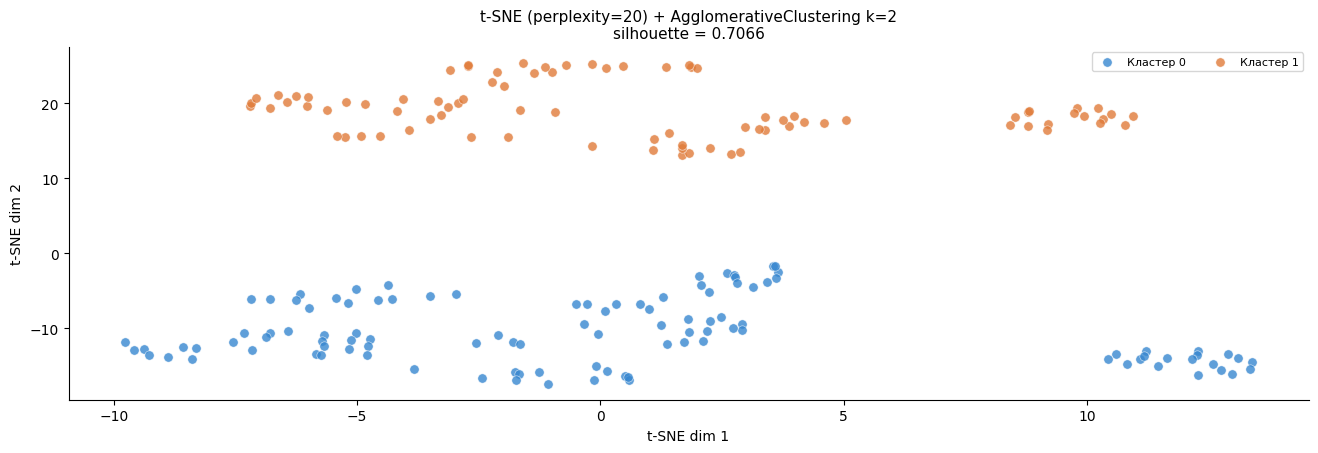

In [38]:
fig = plt.figure(figsize=(16, 11))
ax_main = fig.add_subplot(gs[1, 0:2])
for cid in range(best_k):
    m = labels_best == cid
    ax_main.scatter(X_best[m, 0], X_best[m, 1],
                    c=COLORS[cid % len(COLORS)], s=45, alpha=0.8,
                    edgecolors='white', linewidths=0.4, label=f'Кластер {cid}')
ax_main.set_title(
    f't-SNE (perplexity={best_perp}) + AgglomerativeClustering k={best_k}\n'
    f'silhouette = {best_sil:.4f}', fontsize=11)
ax_main.set_xlabel('t-SNE dim 1')
ax_main.set_ylabel('t-SNE dim 2')
ax_main.legend(fontsize=8, ncol=2)
ax_main.spines[['top','right']].set_visible(False)

plt.show()

**Вывод:**
• Лучший silhouette достигается при perplexity=20, k=2, silhouette=0.7066.
   Это ВЫШЕ, чем без редукции (0.566) и тем более выше PCA (0.3806).

**Perplexity.** Оптимум — perplexity=20: при малых значениях (5–10) алгоритм смотрит только на ближайших соседей и дробит данные на мелкие рыхлые облака. При больших (50+) — сглаживает локальную структуру, кластеры начинают сливаться. Диапазон 18–25 даёт наилучшую визуальную сепарацию.

**Число кластеров.** Технически лучший ответ — k=2 (силуэт 0.7066): t-SNE разбивает покупателей на два чётких облака — «активные» (высокий spending_score, график f — зелёный) и «пассивные» (красный). Для бизнеса k=5 (силуэт 0.566) по-прежнему осмысленнее — он сохраняет тонкие различия между сегментами при приемлемом качестве.

## Задание 10. Интерпретация результатов.

- В исходный датафрейм добавьте столбец с предсказанием номера кластера.
- Далее в разрезе кластеров посмотрите на средние/медианные/модальные значения всех остальных признаков. 

> Для наиболее наглядной интерпретации используйте полярную диаграмму или тепловую карту для таблиц агрегированных значений.

In [39]:
X = scaled_df[['annual_income', 'spending_score']]
kmeans = KMeans(n_clusters=5, random_state=42)
predictions = kmeans.fit_predict(X)
predictions = kmeans.labels_
df['cl_kmeans_s'] = predictions
df.groupby('cl_kmeans_s')[['age', 'annual_income', 'spending_score']].mean()

,age,annual_income,spending_score
cl_kmeans_s,,,
0,43.128205,54.615385,50.025641
1,40.529412,82.647059,18.764706
2,25.272727,25.727273,79.363636
3,32.571429,82.257143,82.171429
4,45.217391,26.304348,20.913043


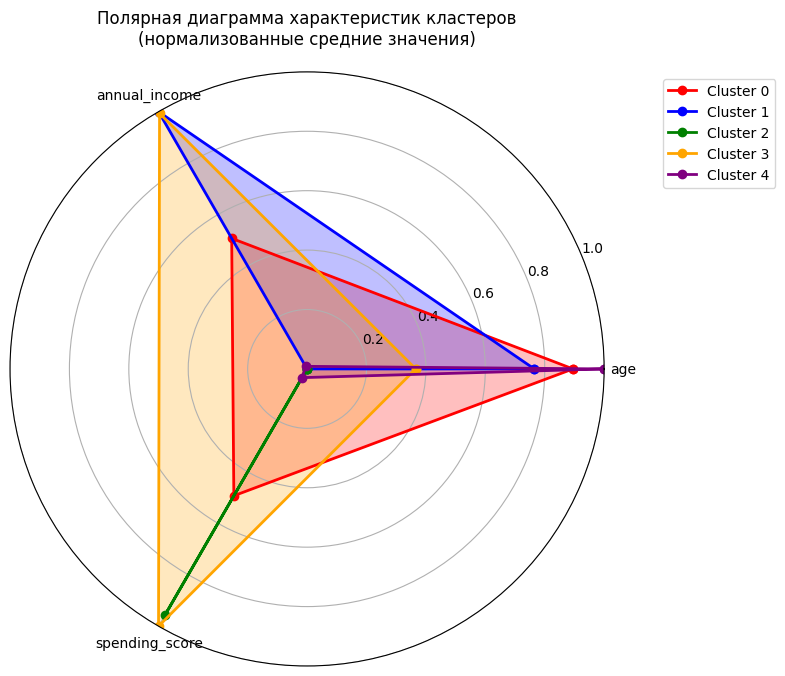

In [40]:
# Выполняем кластеризацию и получаем средние значения по кластерам
kmeans = KMeans(n_clusters=5, random_state=42)
predictions = kmeans.fit_predict(X)
df['cl_kmeans_s'] = predictions

cluster_means = df.groupby('cl_kmeans_s')[['age', 'annual_income', 'spending_score']].mean()

# Нормализуем данные для полярной диаграммы (чтобы все признаки были в одном масштабе)
scaler = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

# Параметры для полярной диаграммы
categories = list(cluster_means.columns)
N = len(categories)

# Создаём углы для каждого признака (в радианах)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # замыкаем круг

# Настройка графика
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Цвета для кластеров
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Рисуем линии для каждого кластера
for cluster_id in cluster_means_scaled.index:
    # Берём значения для кластера и замыкаем линию
    values = cluster_means_scaled.loc[cluster_id].values
    values = np.concatenate([values, [values[0]]])  # замыкаем фигуру

    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=colors[cluster_id])
    ax.fill(angles, values, alpha=0.25, color=colors[cluster_id])

# Настраиваем отображение
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)  # нормализованные данные от 0 до 1
ax.set_title('Полярная диаграмма характеристик кластеров\n(нормализованные средние значения)', pad=20)

# Легенда и отображение
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()


**Вывод:**
Бизнес-рекомендации по каждому сегменту: \

🔵 Кластер 0 — Молодые активные (53 чел.): тратят активно при среднем доходе — значит, чувствительны к акциям и трендовым новинкам.

🟠 Кластер 1 — VIP-покупатели (39 чел.): самый ценный сегмент. Высокий доход + максимальные расходы. Их не нужно «активировать» — нужно удерживать: программы лояльности, приоритетный сервис, персональные менеджеры.

🟢 Кластер 2 — Зрелые умеренные (52 чел.): расчётливые покупатели. Реагируют на выгодные условия — акции «2+1», накопительные скидки, сезонные распродажи.

🔴 Кластер 3 — Состоятельные пассивные (34 чел.): самый интересный с точки зрения потенциала — деньги есть, но не тратят. Нужен точечный стимул: эксклюзивные предложения, премиум-категории, персональное обращение.

🟣 Кластер 4 — Пожилые стабильные (22 чел.): предсказуемое, лояльное ядро. Ценят удобство и надёжность — долгосрочные клубные программы, удобный сервис, напоминания о регулярных покупках.